<a href="https://colab.research.google.com/github/jasmin-05/Sentiment-Analysis-Project/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data.csv


In [2]:
import pandas as pd

df = pd.read_csv("Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
df.shape

(162980, 2)

In [4]:
df.columns

Index(['clean_text', 'category'], dtype='object')

In [5]:
df.isnull().sum()

,0
clean_text,4
category,7


In [6]:
df=df.dropna()
df.shape

(162969, 2)

In [7]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['category']

print(X.shape)

(162969, 5000)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(130375, 5000)
(32594, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 0.  1. -1. -1.  0. -1.  0. -1.  1.  1.]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9267043014051666


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.91      0.83      0.87      7152
         0.0       0.92      0.98      0.95     11067
         1.0       0.94      0.94      0.94     14375

    accuracy                           0.93     32594
   macro avg       0.92      0.91      0.92     32594
weighted avg       0.93      0.93      0.93     32594



In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 5925   507   720]
 [   86 10825   156]
 [  477   443 13455]]


In [16]:
tweet = ["I am very happy today"]

tweet_vector = vectorizer.transform(tweet)

prediction = model.predict(tweet_vector)

print(prediction)

[1.]


In [17]:
tweet = ["This is the worst day ever"]

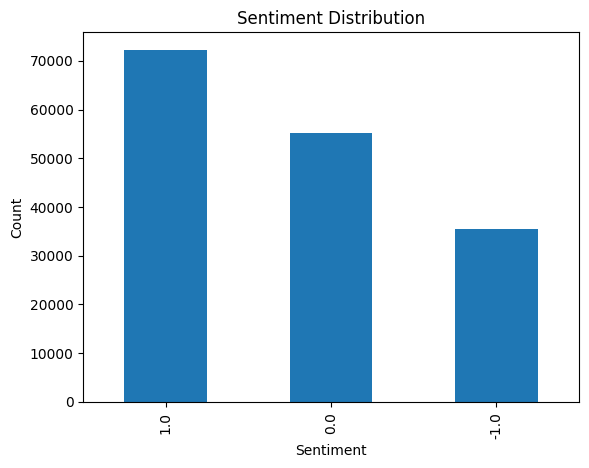

In [18]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

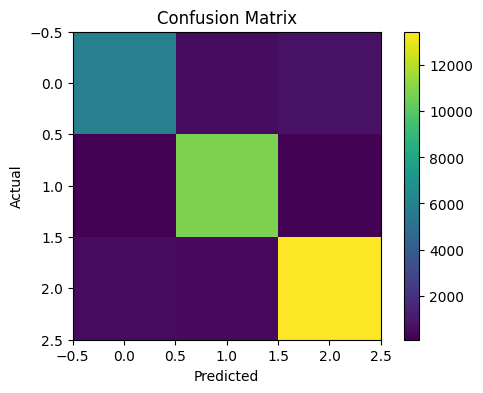

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
tweet = ["I love this product"]

tweet_vector = vectorizer.transform(tweet)

prediction = model.predict(tweet_vector)

print(prediction)

[1.]


In [21]:
tweet = ["This is the worst thing ever"]

In [22]:
tweet_vector = vectorizer.transform(tweet)

prediction = model.predict(tweet_vector)

print(prediction)

[-1.]
